# Project Introduction

**Data**
The Student Depression Dataset is designed to analyze mental health trends and key predictors among students. It combines demographic, academic, and lifestyle information to identify factors associated with depression.

[Source: Kaggle Dataset - Student Depression](https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset/data)

**Data Format:**
*  CSV file, one row per student
*  Total rows: 27,901
*  Total columns: 111

**Variable Categories:**

*   Demographics: Gender, Age, City
*   Academic Factors: CGPA, Academic Pressure, Study Satisfaction
*   Lifestyle: Sleep Duration, Dietary Habits, Work Pressure, Work/Study Hours
*   Additional: Degree, Profession, Financial Stress, Family History of Mental Illness, and suicidal thoughts

**Purpose:**
*   Analyze how academic and lifestyle factors contribute to mental health
*   Predict student depression risks

**Target Variable**: `Depression`  
*   `1` indicates the student is experiencing symptoms of depression
*   `0` indicates the student is not experiencing depression

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings as w
w.filterwarnings('ignore')
import math
import re
import scipy.stats as stats
import plotly.express as px

# Load the data

In [4]:
from google.colab import files
uploaded = files.upload()

Saving student_depression_dataset.csv to student_depression_dataset (1).csv


# EDA

In [5]:
# Load raw dataset
df = pd.read_csv("student_depression_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [6]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [8]:
df.shape

(27901, 18)

In [9]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [11]:
import plotly.express as px
import plotly.graph_objects as go

df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


In [20]:
fig = px.histogram(
    df,
    x='Depression',
    title='Distribution of Depression Levels',
    color='Depression',
    color_discrete_sequence=['lightgreen', 'lightblue']
)
fig.show()

In [23]:
fig = px.histogram(df, x='Gender', color='Depression', barmode='group', title='Depression Distribution by Gender',
                   color_discrete_sequence=['lightgreen', 'lightblue'])
fig.show()

In [26]:
fig = px.histogram(df, x='Age', title='Age Distribution', color_discrete_sequence=['lightgreen'])
fig.show()

In [27]:
fig = px.box(df, x='Depression', y='Academic Pressure', title='Academic Pressure vs Depression')
fig.show()

In [28]:
fig = px.box(df, x='Depression', y='Work Pressure', title='Work Pressure vs Depression')
fig.show()

In [29]:
fig = px.box(df, x='Depression', y='CGPA', title='CGPA vs Depression')
fig.show()

In [50]:
fig = px.box(df, x='Depression', y='Work/Study Hours', title='Work/Study Hours vs Depression')
fig.show()

In [30]:
fig = px.box(df, x='Depression', y='Sleep Duration', title='Sleep Duration vs Depression')
fig.show()

In [51]:
fig = px.box(df, x='Depression', y='Financial Stress', title='Financial Stress vs Depression')
fig.show()

In [31]:
fig = px.scatter(df, x='Study Satisfaction', y='Job Satisfaction', color='Depression',
                 title='Study Satisfaction vs Job Satisfaction')
fig.show()

In [33]:
fig = px.histogram(df, x='Have you ever had suicidal thoughts ?', color='Depression', barmode='group',
                   title='Suicidal Thoughts vs Depression', color_discrete_sequence=['lightgreen', 'lightblue'])
fig.show()

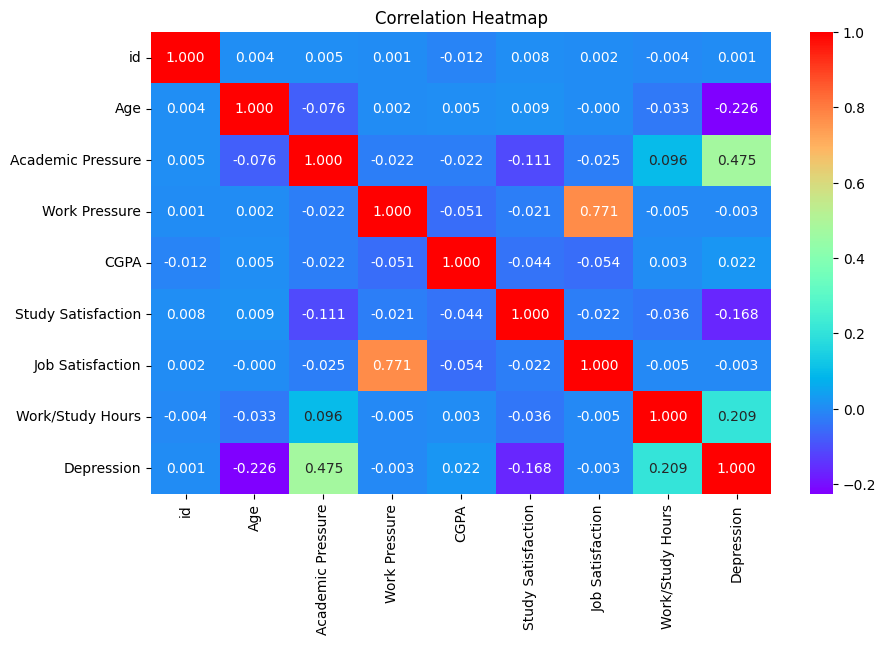

In [43]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='rainbow', fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()

In [46]:
fig = px.histogram(df, x='City', color='Depression', barmode='group', title='Depression Levels by City', color_discrete_sequence=['lightgreen', 'lightblue'])
fig.show()

In [53]:
fig = px.histogram(df, x='Dietary Habits', color='Depression', barmode='group', title='Dietary Habits vs Depression', color_discrete_sequence=['lightgreen', 'lightblue'])
fig.show()

In [55]:
fig = px.histogram(df, x='Family History of Mental Illness', color='Depression', barmode='group',
                   title='Family History of Mental Illness vs Depression', color_discrete_sequence=['lightgreen', 'lightblue'])
fig.show()

In [58]:
fig = px.box(df, x='Degree', y='CGPA', color='Depression', title='Distribution of CGPA by Degree')
fig.show()

# Data Preprocessing
Before moving into modeling, it's important to make sure that:
*  The target variable Depression is properly stored as a numeric type.
*  All categorical features are clearly identified or encoded as needed.
*   Any columns that should be numeric but are currently stored as text are converted appropriately.

In [63]:
df['Depression'] = pd.to_numeric(df['Depression'], downcast='integer')

# List of columns treated as categorical variables
categorical_features = [
    'Gender', 'City', 'Profession', 'Degree',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

# Convert specified columns to category dtype
for feature in categorical_features:
    df[feature] = df[feature].astype('category')

print(f"Values in Sleep Duration column: {df['Sleep Duration'].unique()}")
print(f"Values in Financial Stress column: {df['Financial Stress'].unique()}")

Values in Sleep Duration column: ["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"
 'Others']
Values in Financial Stress column: ['1.0' '2.0' '5.0' '3.0' '4.0' '?']


In [66]:
# parse sleep hours from text
def parse_sleep_hours(value):
    pattern = r"(\d+\.?\d*)"
    found = re.search(pattern, str(value))
    return float(found.group(1)) if found else np.nan

df['Sleep Duration'] = df['Sleep Duration'].apply(parse_sleep_hours)

# Treat 'Financial Stress' as a categorical feature
if df['Financial Stress'].dtype != 'category':
    df['Financial Stress'] = pd.Categorical(df['Financial Stress'])

print(df[['Sleep Duration', 'Financial Stress']].sample(5))


       Sleep Duration Financial Stress
22027             7.0              4.0
17870             7.0              3.0
4463              5.0              2.0
7867              5.0              1.0
6199              5.0              2.0


In [68]:
# missing values per column
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 id                                        0
Gender                                    0
Age                                       0
City                                      0
Profession                                0
Academic Pressure                         0
Work Pressure                             0
CGPA                                      0
Study Satisfaction                        0
Job Satisfaction                          0
Sleep Duration                           18
Dietary Habits                            0
Degree                                    0
Have you ever had suicidal thoughts ?     0
Work/Study Hours                          0
Financial Stress                          0
Family History of Mental Illness          0
Depression                                0
dtype: int64


In [70]:
# Fill missing values in numeric columns using median strategy
target_columns = ['Sleep Duration']

for feature in target_columns:
    missing_count = df[feature].isnull().sum()
    if missing_count:
        median_value = df[feature].median()
        df[feature] = df[feature].fillna(median_value)

# Data visualization after data cleaning

In [77]:
fig = px.scatter(df, x="CGPA", y="Study Satisfaction", color="Depression",
                 hover_data=['Age', 'Gender', 'Academic Pressure'],
                 title="CGPA vs Study Satisfaction by Depression")
fig.show()



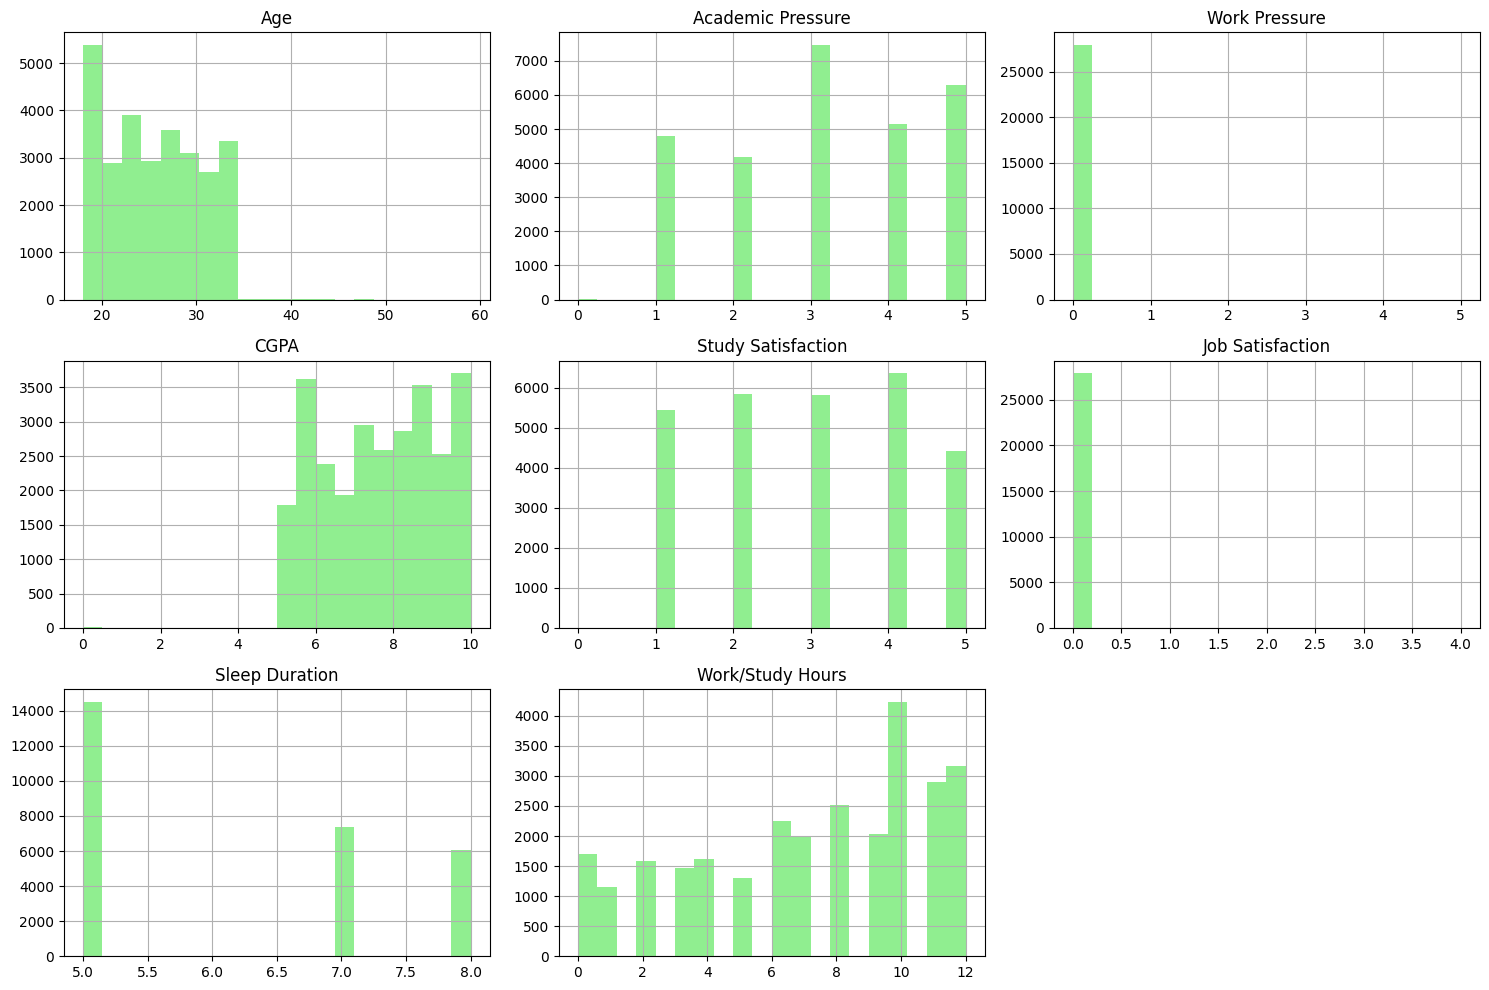

In [80]:
features = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Work/Study Hours']
df[features].hist(bins=20, figsize=(15,10), color='lightgreen')
plt.tight_layout()
plt.show()

In [83]:
# Hypothesis Testing
# Extract academic pressure scores by depression status
dep_scores = df.loc[df['Depression'] == 1, 'Academic Pressure']
non_dep_scores = df.loc[df['Depression'] == 0, 'Academic Pressure']

# Display the number of samples per group
print(f"Number of depression cases: {dep_scores.shape[0]}")
print(f"Number of non-depression cases: {non_dep_scores.shape[0]}")

# Proceed only if both groups have sufficient data
if (dep_scores.size >= 3) and (non_dep_scores.size >= 3):

    # Perform Independent Samples T-Test
    t_statistic, p_value_t = stats.ttest_ind(dep_scores, non_dep_scores, equal_var=False)
    print(f"T-Test: t = {t_statistic:.3f}, p = {p_value_t:.3f}")

    # Perform Mann-Whitney U Test (non-parametric)
    u_statistic, p_value_u = stats.mannwhitneyu(dep_scores, non_dep_scores, alternative='two-sided')
    print(f"Mann-Whitney U Test: U = {u_statistic:.3f}, p = {p_value_u:.3f}")

else:
    print("Insufficient sample size for statistical comparison.")

Number of depression cases: 16336
Number of non-depression cases: 11565
T-Test: t = 89.314, p = 0.000
Mann-Whitney U Test: U = 145556846.500, p = 0.000


In [93]:
# To capture the combined effect of academic and work-related pressures,
# we created a new feature Total Pressure by summing the Academic Pressure and Work Pressure variables.
# This composite feature may better reflect the overall stress burden on individuals and potentially reveal stronger associations with depression outcomes.

df ['Total Pressure'] = df['Academic Pressure'] + df['Work Pressure']

In [94]:
# Identify categorical variables for encoding (excluding the target variable)
categorical_vars = [
    'Gender', 'City', 'Profession', 'Degree',
    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Financial Stress'
]

encoded_df = pd.get_dummies(df, columns=categorical_vars, prefix_sep='_', drop_first=True)

In [106]:
# model building
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = encoded_df.drop(columns=['Depression', 'id', 'Dietary Habits']).astype(float).values
y = encoded_df['Depression'].values

np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train = X[train_idx, :]
X_val = X[val_idx, :]
X_test = X[test_idx, :]


In [109]:
class MyStandardScaler:
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1
    def transform(self, X):
        return (X - self.mean_) / self.std_
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

scaler = MyStandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def _activation(self, x):
        return np.where(x > 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self._activation(linear_output)
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._activation(linear_output)

model = Perceptron(learning_rate=0.01, n_iters=1000)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, r2_score

# Training performance
print("Train Set")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train, zero_division=0))
print("Recall:", recall_score(y_train, y_pred_train, zero_division=0))
print("F1 Score:", f1_score(y_train, y_pred_train, zero_division=0))

Train Set
Accuracy: 0.7654377880184332
Precision: 0.8068730982638267
Recall: 0.7881807850336567
F1 Score: 0.7974174147614205


In [122]:
# Validation performance
print("Validation Set")
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val, zero_division=0))
print("Recall:", recall_score(y_val, y_pred_val, zero_division=0))
print("F1 Score:", f1_score(y_val, y_pred_val, zero_division=0))


Validation Set
Accuracy: 0.7734767025089606
Precision: 0.8134171907756813
Recall: 0.7941056078591895
F1 Score: 0.8036454018227009


In [123]:
# Test performance
print("Test Set")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_test, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_test, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))


Test Set
Accuracy: 0.7634973721930244
Precision: 0.8017312448474856
Recall: 0.7925835370823145
F1 Score: 0.7971311475409836
Confusion Matrix:
 [[1251  481]
 [ 509 1945]]


In [113]:
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))


Confusion Matrix (Test):
[[1251  481]
 [ 509 1945]]


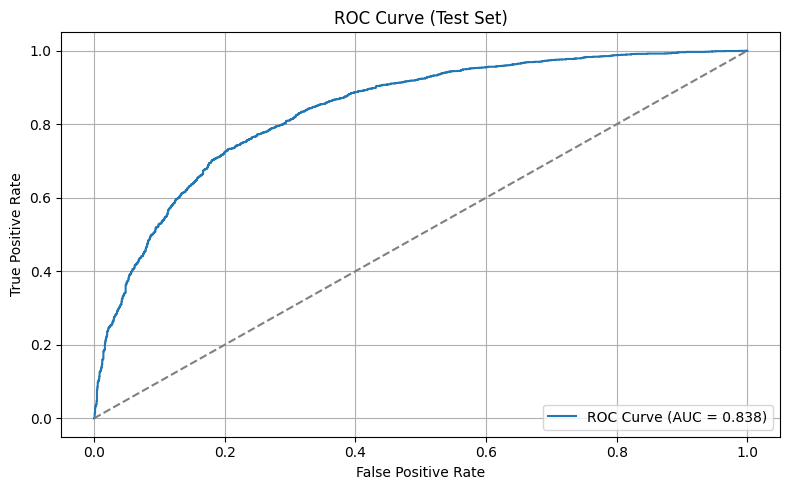

In [117]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


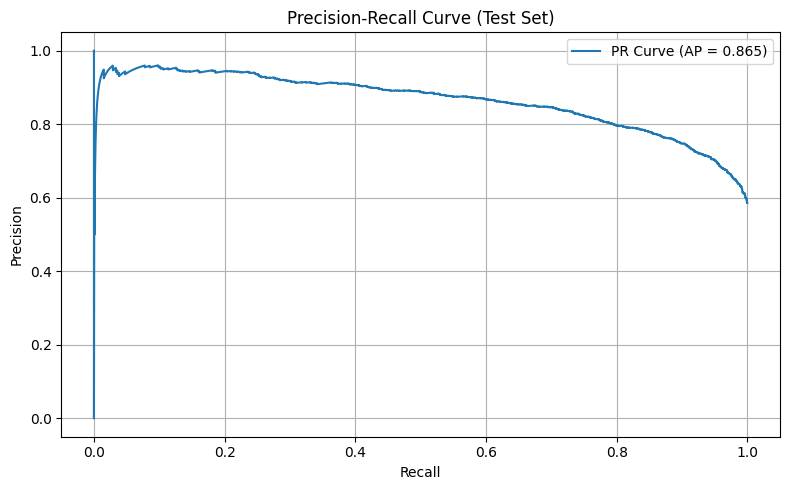

In [118]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'PR Curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()